# A biological discovery with CellSweep: removing ambient tumor‑RNA without erasing the tumor

**Dataset:** 10k Human DTC (dissociated tumor cell) Melanoma, 5′ GEM‑X (10x Genomics, 2024) — a primary human melanoma tumor profiled by scRNA‑seq.

**The problem.** In tumor scRNA‑seq the malignant cells are extreme transcriptional outliers: a melanoma cell carries hundreds of copies of melanocyte/melanoma antigens (`MLANA`, `PMEL`/gp100, `TYR`, `DCT`, `PRAME`, `S100B`, `MITF`, `SOX10`). Lysis during dissociation spills this RNA into the droplet "soup", and every barcode captures some — so T cells, B cells and myeloid cells pick up spurious **melanoma‑antigen expression** that is pure ambient contamination. This corrupts exactly the analyses people run on tumors: antigen‑specificity calls, malignant‑vs‑immune classification, and differential expression in the microenvironment. (`PRAME`, `MLANA`, gp100/`PMEL` and the `MAGE` antigens are themselves diagnostic markers and immunotherapy targets, so false positives are not academic.)

**What a good tool must do — two things at once.** *(1)* erase the ambient antigen signal from non‑tumor cells (**specificity**), and *(2)* keep the genuine antigen signal in the tumor cells (**sensitivity**). We benchmark CellSweep against SoupX, CellBender, scAR and DecontX on both axes, **at the count level and at the single‑cell level**, and then show with a scanpy differential‑expression analysis that tools which look equivalent on those summary metrics behave very differently downstream — and that CellSweep is the one you can trust.

All five tools were run with the project's standard pipeline (`notebooks/benchmarking.ipynb`, `scripts/run_soupx.R`, `scripts/run_decontx.R`, `scripts/run_scar.py`, CellBender 0.3.0, and `cellsweep.denoise_count_matrix`); their output matrices already live in `notebooks/data/melanoma/`. This notebook is the **downstream biological analysis** on top of those outputs.

In [1]:
import os, numpy as np, pandas as pd, scipy.sparse as sp
import anndata as ad, scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import cellsweep.utils as cs_utils

sc.settings.verbosity = 0
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

DATA = os.path.join("data", "melanoma")
OUT  = os.path.join("output", "melanoma_discovery")
os.makedirs(OUT, exist_ok=True)

TOOL_ORDER = ["raw", "cellsweep", "cellbender", "soupx", "decontx", "scar"]
TOOL_LABEL = {"raw":"Raw","cellsweep":"CellSweep","cellbender":"CellBender",
              "soupx":"SoupX","decontx":"DecontX","scar":"scAR"}
TOOL_COLOR = {"raw":"#9aa0a6","cellsweep":"#d6336c","cellbender":"#4C72B0",
              "soupx":"#55A868","decontx":"#8172B3","scar":"#CCB974"}
TOOLS = ["cellsweep","cellbender","soupx","decontx","scar"]

## 1. Assemble an aligned matrix of all five tools

We load the raw count matrix and each tool's denoised output, restrict to the cells and genes they all share, and stack them so every matrix has identical barcodes and genes. Cell‑type labels come from CellSweep's CellTypist annotation (`Adult_Human_Skin`). The compact result is cached so the notebook re‑runs in seconds.

In [2]:
CACHE = f"{DATA}/melanoma_combined_cache.h5ad"

def build_cache():
    print("Building aligned cache from raw + 5 tool outputs (one-time)...")
    acs = ad.read_h5ad(f"{DATA}/melanoma_output_cellsweep.h5ad"); acs.var_names_make_unique()
    acs = acs[~acs.obs["is_empty"].astype(bool)].copy()                       # CellSweep-called real cells
    araw = cs_utils.load_adata(f"{DATA}/10k_Human_DTC_Melanoma_5p_gemx_Multiplex_count_raw_feature_bc_matrix.h5", gex_only=True); araw.var_names_make_unique()
    acb = sc.read_10x_h5(f"{DATA}/melanoma_output_cellbender_filtered.h5", gex_only=False); acb.var_names_make_unique()
    asx = cs_utils.load_adata(f"{DATA}/melanoma_output_soupx"); asx.var_names_make_unique()
    adx = cs_utils.load_adata(f"{DATA}/melanoma_output_decontx")
    adx.obs_names = [n.replace("GRCh38_", "", 1) for n in adx.obs_names]; adx.var_names_make_unique()
    asc = ad.read_h5ad(f"{DATA}/melanoma_output_scar.h5ad"); asc.var_names_make_unique()
    tdict = {"cellsweep":acs,"cellbender":acb,"soupx":asx,"decontx":adx,"scar":asc}
    cells = set.intersection(set(araw.obs_names), *[set(a.obs_names) for a in tdict.values()])
    cells = [c for c in acs.obs_names if c in cells]
    genes = set.intersection(set(araw.var_names), *[set(a.var_names) for a in tdict.values()])
    genes = [g for g in acs.var_names if g in genes]
    aX = lambda a: sp.csr_matrix(a[cells, genes].X)
    comb = ad.AnnData(X=aX(araw),
                      obs=acs[cells].obs[["celltype","is_empty","cell_ambient_fraction","alpha_hat"]].copy(),
                      var=acs[:, genes].var.copy())
    comb.obs_names, comb.var_names = list(cells), list(genes)
    for n, a in tdict.items(): comb.layers[n] = aX(a)
    comb.write_h5ad(CACHE)
    return comb

a = ad.read_h5ad(CACHE) if os.path.exists(CACHE) else build_cache()
print(f"Aligned object: {a.n_obs:,} cells x {a.n_vars:,} genes; layers = {list(a.layers)}")
mats = {"raw": a.X, **{t: a.layers[t] for t in TOOLS}}

Aligned object: 11,074 cells x 38,584 genes; layers = ['cellbender', 'cellsweep', 'decontx', 'scar', 'soupx']


In [3]:
# Total counts each tool removes -- a first signature of under- vs over-correction.
raw_tot = a.X.sum()
summary = []
for t in TOOLS:
    d = (a.X - a.layers[t]).copy(); d.data = np.clip(d.data, 0, None)
    summary.append((TOOL_LABEL[t], int(d.sum()), 100*d.sum()/raw_tot))
print(pd.DataFrame(summary, columns=["tool","counts_removed","pct_of_raw"]).to_string(index=False))

      tool  counts_removed  pct_of_raw
 CellSweep        13807539    6.442855
CellBender         1307063    0.609900
     SoupX         2153603    1.004911
   DecontX        13429377    6.266398
      scAR        83688893   39.050796


## 2. Two unambiguous anchor populations

The skin CellTypist model is noisy on this tumor's immune compartment, but two populations are rock‑solid by canonical markers and are all we need:

- **Tumor / melanocytes** — the only cells with real melanoma‑antigen expression (mean antigen score ~150 vs <5 everywhere else).
- **T cells** (`CD3D/CD3E/CD2/TRAC⁺`) — a large, unambiguous population that should be **completely negative** for melanoma antigens. Any antigen⁺ T cell is, by construction, ambient contamination.

In [4]:
ct = a.obs["celltype"].astype(str)
gi = {g:i for i,g in enumerate(a.var_names)}
def col(X, g):
    c = X[:, gi[g]]; return np.asarray(c.todense()).ravel() if sp.issparse(c) else np.asarray(c).ravel()

tumor    = (ct == "Melanocyte").values
tcell    = ct.isin(["Th","Tc","Treg"]).values
nontumor = (~tumor) & (~ct.isin(["Inf_mac","F2"]).values)   # everything except tumor + 2 tumor-doublet-y labels

lin = {"T cell":["CD3D","CD3E","CD2","TRAC"], "Myeloid":["LYZ","C1QA","CD68","AIF1"],
       "B/Plasma":["MS4A1","CD79A","MZB1"], "Tumor":["MLANA","PMEL","TYR","S100B","PRAME"]}
val = {grp:{ "T cells":np.mean([col(a.X,g)[tcell].mean() for g in gs if g in gi]),
             "Tumor":  np.mean([col(a.X,g)[tumor].mean() for g in gs if g in gi]) }
       for grp,gs in lin.items()}
print(f"tumor cells = {tumor.sum()},  T cells = {tcell.sum()},  non-tumor (negative set) = {nontumor.sum()}\n")
print(pd.DataFrame(val).round(2).to_string())

tumor cells = 370,  T cells = 4978,  non-tumor (negative set) = 10624

         T cell  Myeloid  B/Plasma       Tumor
T cells    3.94     0.14      0.74    0.040000
Tumor      1.25     4.39      1.65  181.059998


## 3. The artifact: melanoma antigens bleed into T cells

We define a panel of clinically relevant melanoma antigens (melanocyte differentiation antigens + the cancer‑testis/diagnostic antigen `PRAME`) expressed in the tumor cells of this sample. In the **raw** data these genes are detectable in a meaningful fraction of T cells — pure ambient signal.

Antigen panel: ['MLANA', 'PMEL', 'TYR', 'DCT', 'TYRP1', 'PRAME', 'S100B', 'MITF', 'SOX10', 'MC1R', 'GPR143']


/home/jrich/tmp/ipykernel_772893/2050909860.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(PANEL, rotation=45, ha="right")


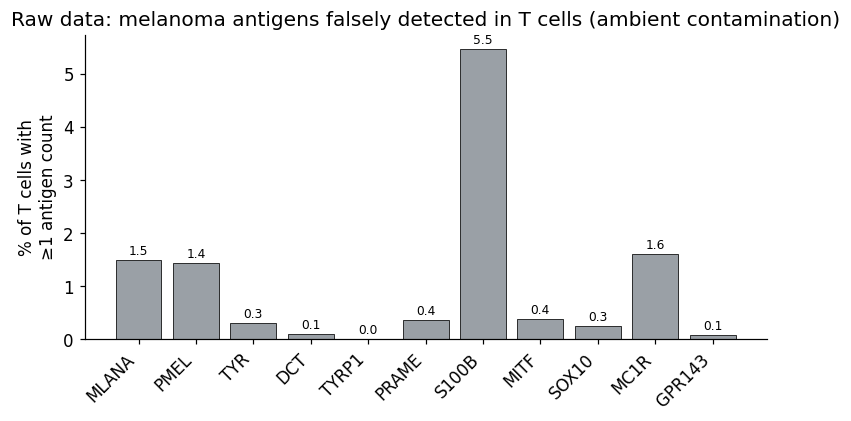

In [5]:
PANEL = [g for g in ["MLANA","PMEL","TYR","DCT","TYRP1","PRAME","S100B","MITF","SOX10","MC1R","GPR143"]
         if g in gi and col(a.X, g)[tumor].sum() > 0]
print("Antigen panel:", PANEL)

fp_raw = pd.Series({g: 100*np.mean(col(a.X, g)[tcell] >= 1) for g in PANEL})
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(PANEL, fp_raw.values, color="#9aa0a6", edgecolor="k", lw=.5)
ax.set_ylabel("% of T cells with\n≥1 antigen count")
ax.set_title("Raw data: melanoma antigens falsely detected in T cells (ambient contamination)")
ax.set_xticklabels(PANEL, rotation=45, ha="right")
for x,(g,v) in enumerate(fp_raw.items()): ax.text(x, v+0.05, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
plt.savefig(f"{OUT}/fig1_raw_antigen_false_positives.png"); plt.show()

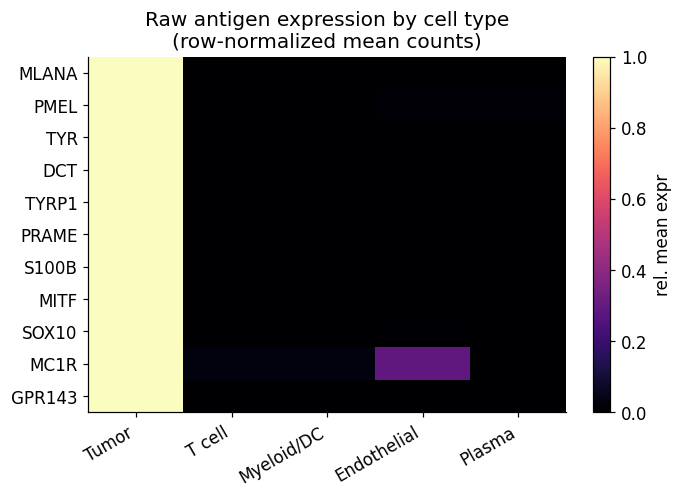

In [6]:
# Antigen expression by cell type (raw, mean counts) -- the "smear" out of the tumor compartment.
groups = {"Tumor":tumor, "T cell":tcell, "Myeloid/DC":ct.isin(["Macro_2","DC1","DC2","Inf_mac"]).values,
          "Endothelial":ct.isin(["LE1","VE3"]).values, "Plasma":ct.isin(["Plasma"]).values}
H = pd.DataFrame({grp: {g: col(a.X, g)[m].mean() for g in PANEL} for grp, m in groups.items()})
Hn = H.div(H.max(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
im = ax.imshow(Hn.values, aspect="auto", cmap="magma")
ax.set_xticks(range(H.shape[1])); ax.set_xticklabels(H.columns, rotation=30, ha="right")
ax.set_yticks(range(len(PANEL))); ax.set_yticklabels(PANEL)
ax.set_title("Raw antigen expression by cell type\n(row-normalized mean counts)")
fig.colorbar(im, ax=ax, fraction=0.046, label="rel. mean expr")
plt.savefig(f"{OUT}/fig2_antigen_by_celltype_raw.png"); plt.show()

## 4. Sensitivity & specificity, at two resolutions

Treat ambient removal as a detection problem: the antigen *should* be detected in tumor cells (positives) and *should not* be detected in non‑tumor cells (negatives). We score every tool two ways.

**Count level** (how much antigen *mass* is in the right place):
- **Sensitivity** = antigen counts retained in tumor cells ÷ antigen counts in tumor cells in raw.
- **Specificity** = fraction of the ambient antigen mass (non‑tumor counts) that was removed = 1 − (non‑tumor counts after ÷ non‑tumor counts in raw).

**Cell level** (threshold = 1 count — the calls a marker/DE test actually sees):
- **Sensitivity** = % of tumor cells still antigen⁺ (≥1 count).
- **Specificity** = % of non‑tumor cells correctly antigen‑negative (0 counts) = 1 − false‑positive rate.

Each value is averaged over the antigen panel.

In [7]:
def count_sens(X, g): return col(X,g)[tumor].sum() / max(col(a.X,g)[tumor].sum(), 1e-9)
def count_spec(X, g):
    raw_amb = col(a.X,g)[nontumor].sum()
    return 1 - col(X,g)[nontumor].sum() / raw_amb if raw_amb > 0 else np.nan
def cell_sens(X, g):  return np.mean(col(X,g)[tumor] >= 1)
def cell_spec(X, g):  return np.mean(col(X,g)[nontumor] < 1)

cnt = pd.DataFrame({k: {"sensitivity":np.nanmean([count_sens(X,g) for g in PANEL]),
                        "specificity":np.nanmean([count_spec(X,g) for g in PANEL])} for k,X in mats.items()}).T
cel = pd.DataFrame({k: {"sensitivity":np.mean([cell_sens(X,g) for g in PANEL]),
                        "specificity":np.mean([cell_spec(X,g) for g in PANEL])} for k,X in mats.items()}).T
print("COUNT level (mean over panel):\n", cnt.round(3), "\n")
print("CELL level, threshold=1 (mean over panel):\n", cel.round(4))

COUNT level (mean over panel):
             sensitivity  specificity
raw               1.000        0.000
cellsweep         0.992        0.657
cellbender        0.998        0.617
soupx             0.998        0.476
decontx           0.980        0.758
scar              0.737        0.929 

CELL level, threshold=1 (mean over panel):
             sensitivity  specificity
raw              0.7283       0.9894
cellsweep        0.6622       0.9990
cellbender       0.7246       0.9957
soupx            0.6631       0.9983
decontx          0.6592       0.9991
scar             0.6784       0.9998


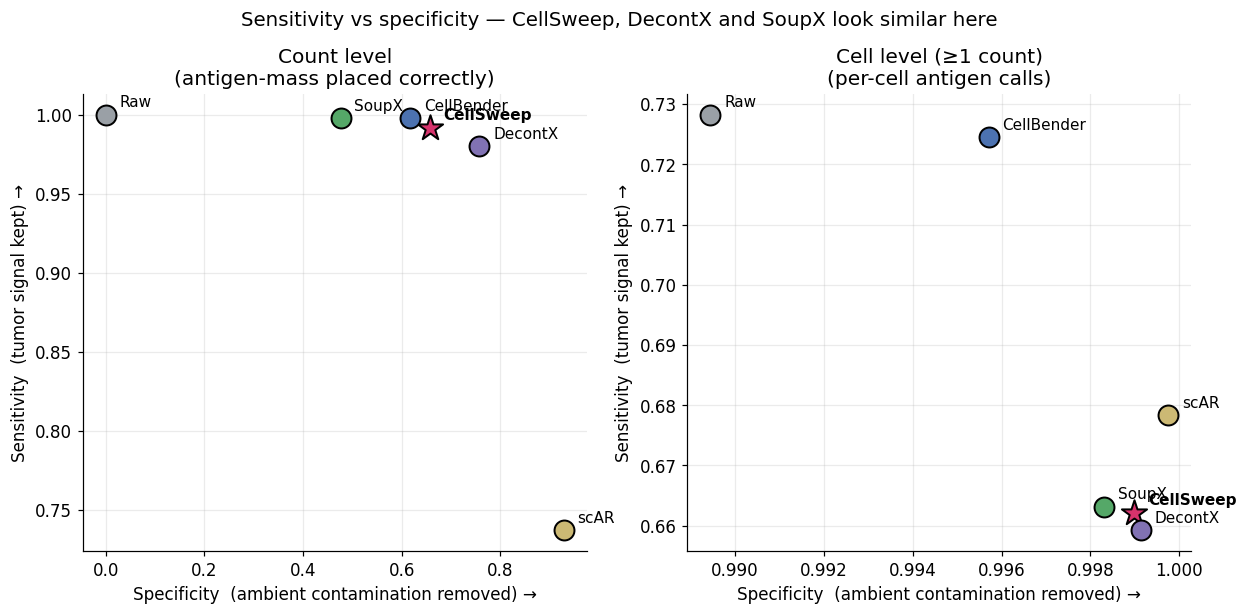

In [8]:
def scatter(ax, df, title, ylim=None, xlim=None):
    for k in TOOL_ORDER:
        ax.scatter(df.loc[k,"specificity"], df.loc[k,"sensitivity"],
                   s=300 if k=="cellsweep" else 170, color=TOOL_COLOR[k], edgecolor="k", lw=1.3,
                   marker="*" if k=="cellsweep" else "o", zorder=3)
        ax.annotate(TOOL_LABEL[k], (df.loc[k,"specificity"], df.loc[k,"sensitivity"]),
                    textcoords="offset points", xytext=(9,5),
                    fontweight="bold" if k=="cellsweep" else "normal", fontsize=10)
    ax.set_xlabel("Specificity  (ambient contamination removed) →")
    ax.set_ylabel("Sensitivity  (tumor signal kept) →")
    ax.set_title(title); ax.grid(alpha=.25)
    if ylim: ax.set_ylim(*ylim)
    if xlim: ax.set_xlim(*xlim)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
scatter(axes[0], cnt, "Count level\n(antigen-mass placed correctly)")
scatter(axes[1], cel, "Cell level (≥1 count)\n(per-cell antigen calls)")
fig.suptitle("Sensitivity vs specificity — CellSweep, DecontX and SoupX look similar here", y=1.02, fontsize=13)
plt.savefig(f"{OUT}/fig3_sensitivity_specificity_scatters.png"); plt.show()

**Read‑out.** On these summary metrics the field collapses onto a frontier. At the **cell level** especially, **CellSweep, DecontX and SoupX are nearly on top of one another** (specificity ≈ 0.998–0.999, sensitivity ≈ 0.66); at the count level CellSweep and DecontX trade a little sensitivity for specificity while CellBender removes little. scAR is the outlier that buys specificity by sacrificing sensitivity (it deletes real signal). If you stopped here you might call CellSweep, DecontX and SoupX interchangeable. **They are not** — and the way to see it is to run the analysis these matrices exist to support: differential expression.

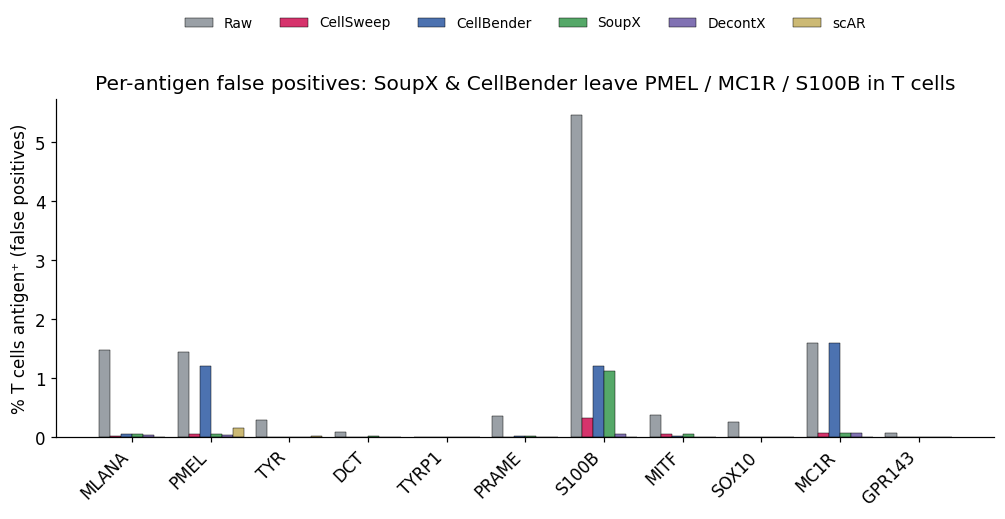

In [9]:
# Per-antigen specificity (cell level) -- where the "similar" tools actually diverge.
fig, ax = plt.subplots(figsize=(11, 4)); x = np.arange(len(PANEL)); w = 0.14
for j,k in enumerate(TOOL_ORDER):
    vals = [100*np.mean(col(mats[k],g)[tcell] >= 1) for g in PANEL]
    ax.bar(x + (j-2.5)*w, vals, w, label=TOOL_LABEL[k], color=TOOL_COLOR[k], edgecolor="k", lw=.3)
ax.set_xticks(x); ax.set_xticklabels(PANEL, rotation=45, ha="right")
ax.set_ylabel("% T cells antigen⁺ (false positives)")
ax.set_title("Per-antigen false positives: SoupX & CellBender leave PMEL / MC1R / S100B in T cells")
ax.legend(ncol=6, fontsize=9, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.28))
plt.savefig(f"{OUT}/fig4_per_antigen_false_positives.png"); plt.show()

## 5. Differential expression: why the choice of tool matters

A researcher's first move with a tumor matrix is to run `sc.tl.rank_genes_groups` on the malignant cells to characterise their program. We do exactly that — **tumor (melanocyte) vs T cells**, Wilcoxon — on each denoised matrix, and inspect three things the summary metrics hid.

In [10]:
keep = tumor | tcell; lab = np.where(tumor[keep], "Tumor", "Tcell")
def de_tumor(X):
    s = ad.AnnData(sp.csr_matrix(X)[keep].copy(),
                   obs=pd.DataFrame({"g":lab}, index=np.arange(keep.sum()).astype(str)),
                   var=pd.DataFrame(index=a.var_names))
    s.X.data = np.clip(s.X.data, 0, None); sc.pp.normalize_total(s, target_sum=1e4); sc.pp.log1p(s)
    sc.tl.rank_genes_groups(s, "g", groups=["Tumor"], reference="Tcell", method="wilcoxon")
    return sc.get.rank_genes_groups_df(s, group="Tumor").set_index("names")
de = {k: de_tumor(X) for k, X in mats.items()}
print("tumor-vs-Tcell DE computed for:", list(de))

tumor-vs-Tcell DE computed for: ['raw', 'cellsweep', 'cellbender', 'soupx', 'decontx', 'scar']


### 5a. Over‑correction silently deletes real markers

`rank_genes_groups` recovers the melanoma program from **every** matrix — the tumor is too distinct to miss. But which antigens survive as *significant* markers (adj p < 0.05, log₂FC > 1) is not the same across tools: **scAR loses `MC1R` and `TYRP1` entirely**, because it scrubbed those genes out of the tumor cells too. An over‑corrector doesn't just clean noise — it can erase the very markers you came to find.

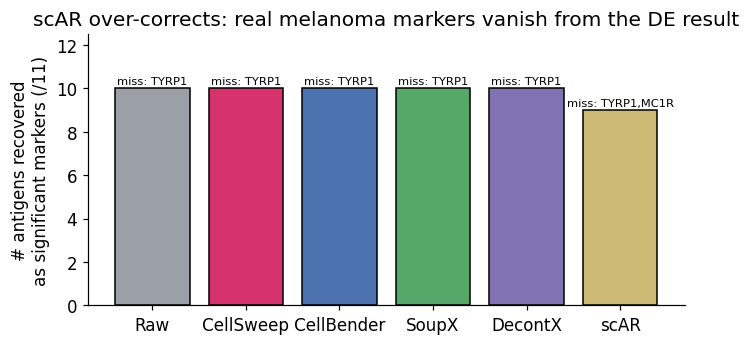

{'Raw': ['MLANA', 'PMEL', 'TYR', 'DCT', 'PRAME', 'S100B', 'MITF', 'SOX10', 'MC1R', 'GPR143'], 'CellSweep': ['MLANA', 'PMEL', 'TYR', 'DCT', 'PRAME', 'S100B', 'MITF', 'SOX10', 'MC1R', 'GPR143'], 'CellBender': ['MLANA', 'PMEL', 'TYR', 'DCT', 'PRAME', 'S100B', 'MITF', 'SOX10', 'MC1R', 'GPR143'], 'SoupX': ['MLANA', 'PMEL', 'TYR', 'DCT', 'PRAME', 'S100B', 'MITF', 'SOX10', 'MC1R', 'GPR143'], 'DecontX': ['MLANA', 'PMEL', 'TYR', 'DCT', 'PRAME', 'S100B', 'MITF', 'SOX10', 'MC1R', 'GPR143'], 'scAR': ['MLANA', 'PMEL', 'TYR', 'DCT', 'PRAME', 'S100B', 'MITF', 'SOX10', 'GPR143']}


In [11]:
def recovered(r): return [g for g in PANEL if r.loc[g,"pvals_adj"]<0.05 and r.loc[g,"logfoldchanges"]>1]
rec = {k: recovered(de[k]) for k in mats}
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar([TOOL_LABEL[k] for k in TOOL_ORDER], [len(rec[k]) for k in TOOL_ORDER],
       color=[TOOL_COLOR[k] for k in TOOL_ORDER], edgecolor="k")
ax.set_ylabel(f"# antigens recovered\nas significant markers (/{len(PANEL)})")
ax.set_title("scAR over-corrects: real melanoma markers vanish from the DE result")
for i,k in enumerate(TOOL_ORDER):
    miss = [g for g in PANEL if g not in rec[k]]
    ax.text(i, len(rec[k])+0.1, "miss: "+",".join(miss) if miss else "all", ha="center", va="bottom", fontsize=7.5)
ax.set_ylim(0, len(PANEL)+1.5)
plt.savefig(f"{OUT}/fig5_marker_recovery.png"); plt.show()
print({TOOL_LABEL[k]: rec[k] for k in mats})

### 5b. Aggressive subtraction destabilises effect sizes

Effect size is how DE results are ranked, thresholded and put on volcano plots. Whenever a tool *hard‑zeros* an antigen out of the reference (T‑cell) group, the fold‑change denominator collapses and the estimate explodes: **DecontX and scAR (and CellBender on the genes it does clean) drive antigen log₂ fold‑changes to extreme, unstable values (≈ 28–35)** — two‑to‑three‑fold above the calibrated estimate. Only **CellSweep and SoupX keep every antigen in a stable, credible band** — but they get there differently: SoupX simply under‑cleans (which is why it fails the per‑cell test in 5c), whereas CellSweep removes the contamination yet leaves a smooth, celltype‑aware residual that keeps effect sizes honest.

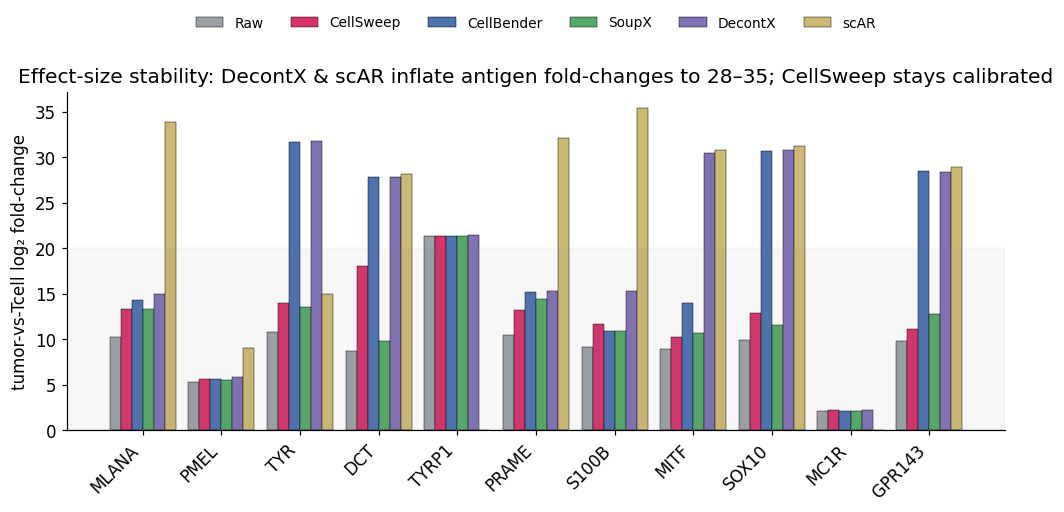

max antigen log2FC per tool: {'Raw': 21.4, 'CellSweep': 21.4, 'CellBender': 31.7, 'SoupX': 21.4, 'DecontX': 31.8, 'scAR': 35.4}


In [12]:
lfc = pd.DataFrame({k: de[k]["logfoldchanges"].reindex(PANEL) for k in mats})
fig, ax = plt.subplots(figsize=(11, 4))
for j,k in enumerate(TOOL_ORDER):
    ax.bar(x + (j-2.5)*w, lfc[k].values, w, label=TOOL_LABEL[k], color=TOOL_COLOR[k], edgecolor="k", lw=.3)
ax.axhspan(0, 20, color="grey", alpha=0.06)
ax.set_xticks(x); ax.set_xticklabels(PANEL, rotation=45, ha="right")
ax.set_ylabel("tumor-vs-Tcell log₂ fold-change")
ax.set_title("Effect-size stability: DecontX & scAR inflate antigen fold-changes to 28–35; CellSweep stays calibrated")
ax.legend(ncol=6, fontsize=9, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.26))
plt.savefig(f"{OUT}/fig6_de_foldchange_calibration.png"); plt.show()
print("max antigen log2FC per tool:", {TOOL_LABEL[k]: round(float(lfc[k].max()),1) for k in mats})

### 5c. Under‑correction leaves false‑positive marker cells

The flip side: a DE/marker test calls a gene "expressed" in a cell whenever it sees a count. Because **SoupX and CellBender under‑correct**, the worst ambient antigens (`S100B`, `PMEL`, `MC1R`) are still detected in hundreds of T cells after denoising — so any per‑cell marker analysis, co‑expression test, or antigen‑specificity claim built on those matrices inherits the artifact. CellSweep (and DecontX) clear it.

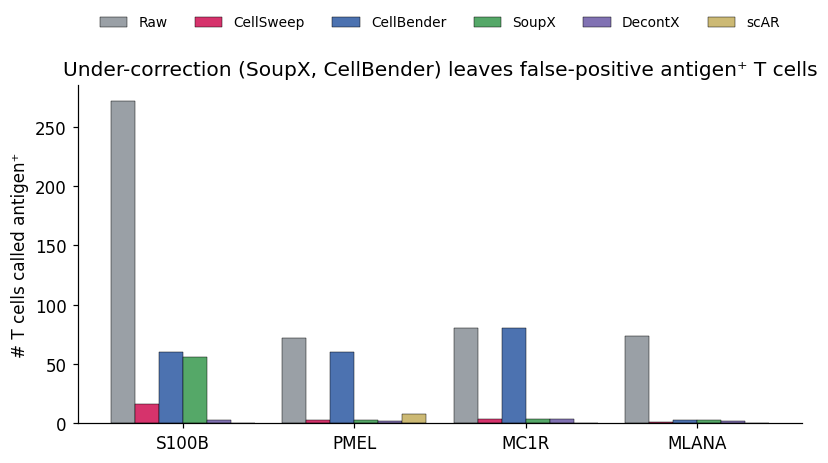

In [13]:
worst = [g for g in ["S100B","PMEL","MC1R","MLANA"] if g in PANEL]
fig, ax = plt.subplots(figsize=(8.5, 4)); xb = np.arange(len(worst)); wb = 0.14
for j,k in enumerate(TOOL_ORDER):
    ax.bar(xb + (j-2.5)*wb, [int(np.sum(col(mats[k],g)[tcell] >= 1)) for g in worst], wb,
           label=TOOL_LABEL[k], color=TOOL_COLOR[k], edgecolor="k", lw=.3)
ax.set_xticks(xb); ax.set_xticklabels(worst)
ax.set_ylabel("# T cells called antigen⁺")
ax.set_title("Under-correction (SoupX, CellBender) leaves false-positive antigen⁺ T cells")
ax.legend(ncol=6, fontsize=9, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.24))
plt.savefig(f"{OUT}/fig7_false_positive_marker_cells.png"); plt.show()

### 5d. The verdict: only CellSweep is clean *and* faithful *and* calibrated

Scoring each tool on the three downstream‑DE failure modes makes the trade‑off explicit. A tool "passes" a column when it (i) loses no markers relative to raw (`TYRP1` is undetectable even in raw, so it is not counted against anyone), (ii) keeps every antigen's fold‑change in the calibrated band (< 25), and (iii) leaves < 10 false‑positive antigen⁺ T cells (averaged over the worst antigens). **CellSweep is the only tool that passes all three.** SoupX and DecontX — the tools that *looked* equivalent to CellSweep in Section 4 — each fail a different one.

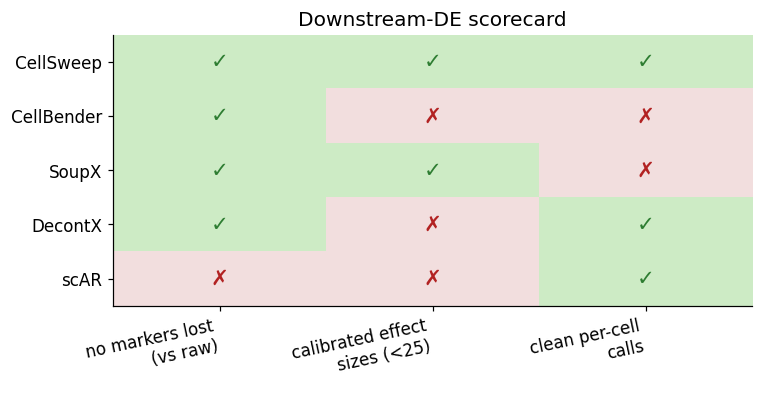

           no markers lost\n(vs raw) calibrated effect\nsizes (<25) clean per-cell\ncalls
CellSweep                       PASS                           PASS                  PASS
CellBender                      PASS                           fail                  fail
SoupX                           PASS                           PASS                  fail
DecontX                         PASS                           fail                  PASS
scAR                            fail                           fail                  PASS


In [14]:
n_raw_markers = len(rec["raw"])
scorecard = pd.DataFrame(index=[TOOL_LABEL[k] for k in TOOLS])
scorecard["no markers lost\n(vs raw)"]      = [len(rec[k]) >= n_raw_markers for k in TOOLS]
scorecard["calibrated effect\nsizes (<25)"] = [float(lfc[k].max()) < 25 for k in TOOLS]
scorecard["clean per-cell\ncalls"]          = [np.mean([np.sum(col(mats[k],g)[tcell]>=1) for g in worst]) < 10 for k in TOOLS]
M = scorecard.astype(int).values
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.imshow(M, aspect="auto", cmap=mpl.colors.ListedColormap(["#f2dede","#cdebc5"]), vmin=0, vmax=1)
ax.set_xticks(range(scorecard.shape[1])); ax.set_xticklabels(scorecard.columns, rotation=12, ha="right")
ax.set_yticks(range(scorecard.shape[0])); ax.set_yticklabels(scorecard.index)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, "✓" if M[i,j] else "✗", ha="center", va="center",
                color="#2e7d32" if M[i,j] else "#b22222", fontweight="bold", fontsize=14)
ax.set_title("Downstream-DE scorecard")
plt.savefig(f"{OUT}/fig8_de_scorecard.png"); plt.show()
print(scorecard.replace({True:"PASS",False:"fail"}).to_string())

### 5e. Does the inflation *reorder* the gene list? Rank concordance with raw

The standard way to compare two ranked gene lists is **Spearman's rank correlation**. We rank the significant tumor‑up genes (defined on raw) by each tool and correlate against raw — two ways: by **significance** (the Wilcoxon score scanpy ranks on by default) and by **log₂ fold‑change**.

The result clarifies exactly what the fold‑change inflation does. Ranked by significance, every tool tracks raw almost perfectly — **except scAR** (ρ ≈ 0.2). Ranked by fold‑change, DecontX and CellBender are still highly concordant with raw (ρ ≈ 0.98–0.99): **their inflation rescales the magnitudes without globally reordering the list.** scAR is the only tool whose reconstruction actually *scrambles* the DE ranking. The one place ordering does break for the hard‑zeroing tools is the **extreme top** of the fold‑change list (right panel): by leaving a smooth, celltype‑aware residual in the reference group, **CellSweep is the only tool that preserves the top‑of‑list order**, while CellBender, DecontX and scAR zero the reference and collapse the top into tied, arbitrarily‑ordered capped values.

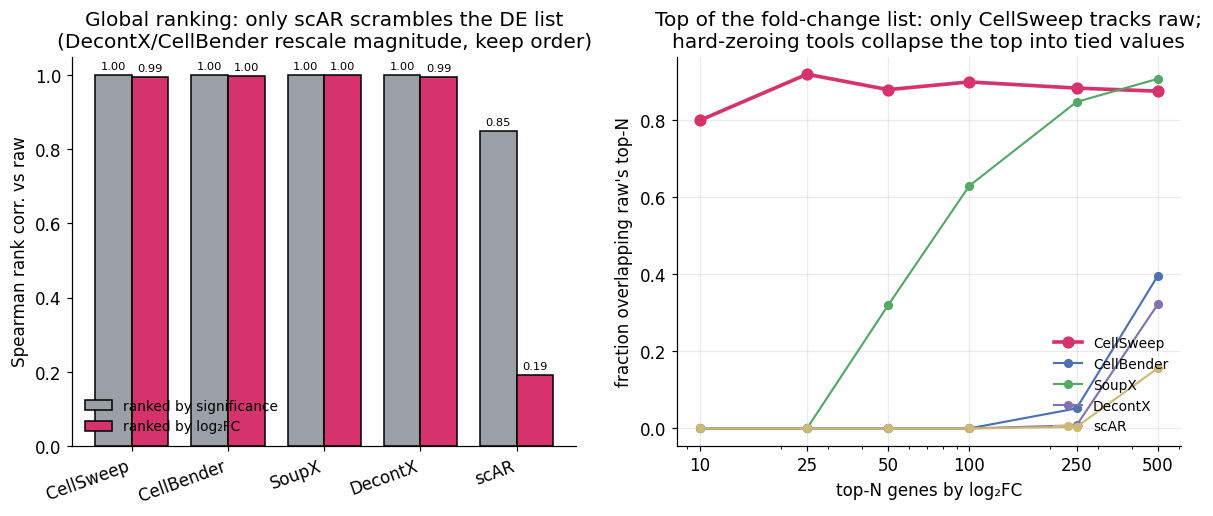

Spearman vs raw (significant genes) -- by significance: {'CellSweep': np.float64(0.999), 'CellBender': np.float64(1.0), 'SoupX': np.float64(1.0), 'DecontX': np.float64(1.0), 'scAR': np.float64(0.85)}
Spearman vs raw (significant genes) -- by log2FC:       {'CellSweep': np.float64(0.994), 'CellBender': np.float64(0.997), 'SoupX': np.float64(1.0), 'DecontX': np.float64(0.995), 'scAR': np.float64(0.193)}


In [15]:
from scipy.stats import spearmanr

rawd = de["raw"]
sigU = rawd[(rawd.pvals_adj < 0.05) & (rawd.logfoldchanges > 1)].index   # raw's significant tumor markers
def spear_vs_raw(colname):
    return {k: spearmanr(rawd.loc[sigU, colname], de[k].loc[sigU, colname]).correlation for k in TOOLS}
sp_score = spear_vs_raw("scores")           # ranking by significance
sp_lfc   = spear_vs_raw("logfoldchanges")   # ranking by fold-change

def topN_overlap(k, N):                      # fraction of raw's top-N FC genes recovered
    raw_top = list(rawd[rawd.pvals_adj < 0.05].sort_values("logfoldchanges", ascending=False).index[:N])
    k_top   = list(de[k][de[k].pvals_adj < 0.05].sort_values("logfoldchanges", ascending=False).index[:N])
    return len(set(raw_top) & set(k_top)) / N
Ns = [10, 25, 50, 100, 250, 500]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

xt = np.arange(len(TOOLS)); wb = 0.38
axA.bar(xt - wb/2, [sp_score[k] for k in TOOLS], wb, label="ranked by significance", color="#9aa0a6", edgecolor="k")
axA.bar(xt + wb/2, [sp_lfc[k]   for k in TOOLS], wb, label="ranked by log₂FC",       color="#d6336c", edgecolor="k")
axA.set_xticks(xt); axA.set_xticklabels([TOOL_LABEL[k] for k in TOOLS], rotation=20, ha="right")
axA.set_ylabel("Spearman rank corr. vs raw"); axA.set_ylim(0, 1.05)
axA.axhline(0, color="k", lw=.6)
axA.set_title("Global ranking: only scAR scrambles the DE list\n(DecontX/CellBender rescale magnitude, keep order)")
axA.legend(fontsize=9, frameon=False, loc="lower left")
for i,k in enumerate(TOOLS):
    axA.text(i-wb/2, sp_score[k]+0.01, f"{sp_score[k]:.2f}", ha="center", va="bottom", fontsize=7.5)
    axA.text(i+wb/2, sp_lfc[k]+0.01,  f"{sp_lfc[k]:.2f}",   ha="center", va="bottom", fontsize=7.5)

for k in TOOLS:
    axB.plot(Ns, [topN_overlap(k, N) for N in Ns], "-o", color=TOOL_COLOR[k],
             lw=2.4 if k=="cellsweep" else 1.4, ms=7 if k=="cellsweep" else 5, label=TOOL_LABEL[k])
axB.set_xlabel("top-N genes by log₂FC"); axB.set_ylabel("fraction overlapping raw's top-N")
axB.set_xscale("log"); axB.set_xticks(Ns); axB.set_xticklabels(Ns)
axB.set_title("Top of the fold-change list: only CellSweep tracks raw;\nhard-zeroing tools collapse the top into tied values")
axB.legend(fontsize=9, frameon=False, loc="lower right"); axB.grid(alpha=.25)

plt.savefig(f"{OUT}/fig9_rank_concordance.png"); plt.show()
print("Spearman vs raw (significant genes) -- by significance:", {TOOL_LABEL[k]: round(sp_score[k],3) for k in TOOLS})
print("Spearman vs raw (significant genes) -- by log2FC:      ", {TOOL_LABEL[k]: round(sp_lfc[k],3) for k in TOOLS})

## 6. CellSweep vs DecontX: where the two best tools diverge

Across Sections 4–5, DecontX was CellSweep's only real rival — close on sensitivity/specificity, clean per‑cell, ranking concordant with raw. So where do they actually *differ*? The answer follows directly from their algorithms: **DecontX** estimates one global contamination distribution and removes it **per cluster** (a multiplicative, per‑cell scaling), whereas **CellSweep** is **celltype‑aware** (per‑celltype expression profiles + a per‑cell ambient fraction in an EM). Three deviations fall out of that difference — all reproducible on this tumor.

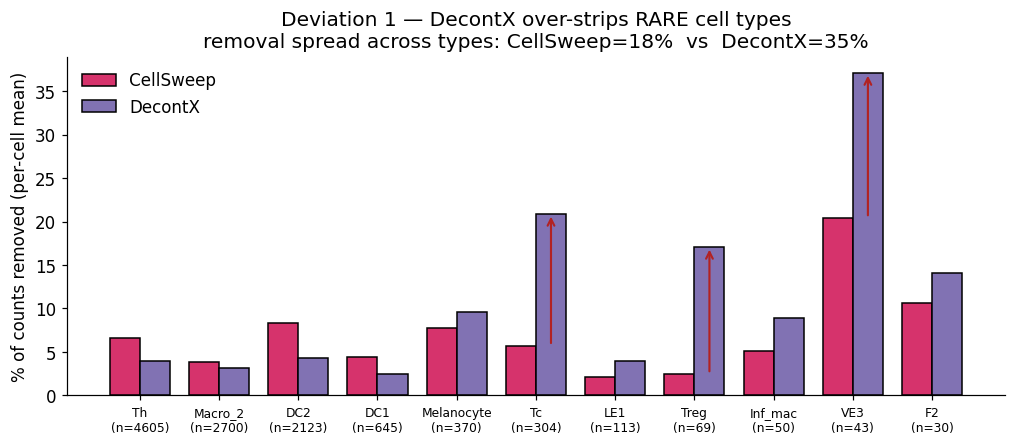

            CellSweep  DecontX     n
Th                6.6      4.0  4605
Macro_2           3.9      3.1  2700
DC2               8.4      4.3  2123
DC1               4.4      2.4   645
Melanocyte        7.8      9.5   370
Tc                5.7     20.9   304
LE1               2.1      3.9   113
Treg              2.4     17.1    69
Inf_mac           5.1      9.0    50
VE3              20.4     37.2    43
F2               10.7     14.1    30


In [16]:
raw = a.X.tocsr(); cs = a.layers["cellsweep"].tocsr(); dx = a.layers["decontx"].tocsr()
rs = np.asarray(raw.sum(1)).ravel()
frac = {"CellSweep": 100*(1 - np.asarray(cs.sum(1)).ravel()/np.clip(rs,1,None)),
        "DecontX":   100*(1 - np.asarray(dx.sum(1)).ravel()/np.clip(rs,1,None))}
vc = ct.value_counts(); cts = [c for c in vc.index if vc[c] >= 30]
remc = pd.DataFrame({t: pd.Series(frac[t], index=a.obs_names).groupby(ct.values).mean() for t in frac}).loc[cts]
remc["n"] = vc.loc[cts]

fig, ax = plt.subplots(figsize=(11, 4)); xx = np.arange(len(cts)); w = 0.38
ax.bar(xx-w/2, remc["CellSweep"], w, label="CellSweep", color=TOOL_COLOR["cellsweep"], edgecolor="k")
ax.bar(xx+w/2, remc["DecontX"],   w, label="DecontX",   color=TOOL_COLOR["decontx"], edgecolor="k")
ax.set_xticks(xx); ax.set_xticklabels([f"{c}\n(n={int(remc.loc[c,'n'])})" for c in cts], fontsize=8)
ax.set_ylabel("% of counts removed (per-cell mean)")
ax.set_title("Deviation 1 — DecontX over-strips RARE cell types\n"
             f"removal spread across types: CellSweep={remc['CellSweep'].max()-remc['CellSweep'].min():.0f}%  "
             f"vs  DecontX={remc['DecontX'].max()-remc['DecontX'].min():.0f}%")
ax.legend(frameon=False)
for i,c in enumerate(cts):
    if remc.loc[c,"DecontX"]-remc.loc[c,"CellSweep"] > 8:
        ax.annotate("", xy=(i+w/2, remc.loc[c,"DecontX"]), xytext=(i+w/2, remc.loc[c,"CellSweep"]),
                    arrowprops=dict(arrowstyle="->", color="#b22222", lw=1.4))
plt.savefig(f"{OUT}/fig10_removal_by_celltype.png"); plt.show()
print(remc.round(1).to_string())

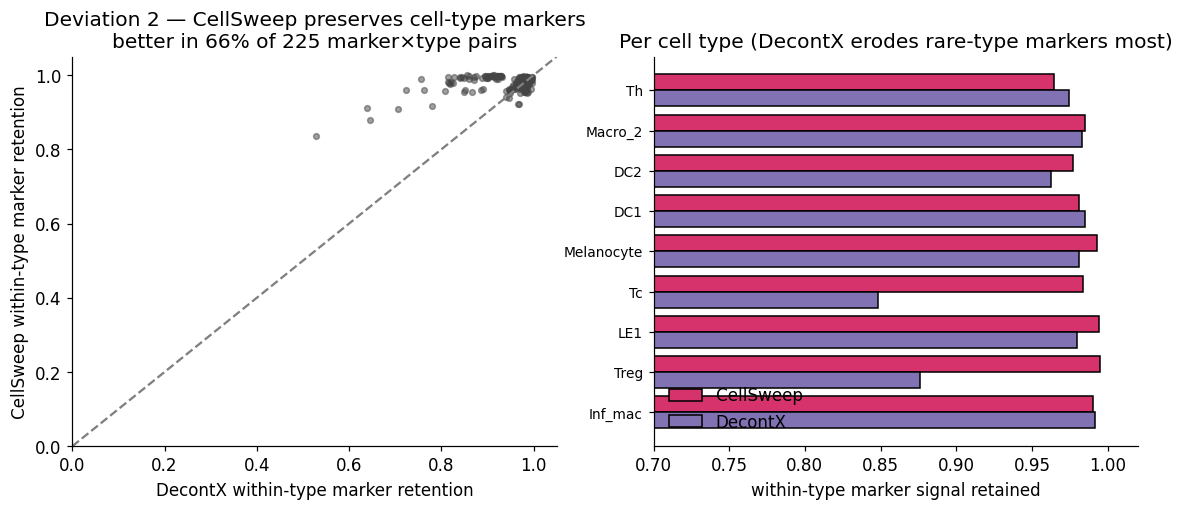

mean within-type retention  CellSweep=0.980  DecontX=0.947


In [17]:
# Markers per celltype defined on RAW (unbiased by either tool); measure within-type retention.
groups = [c for c in ct.value_counts().index if (ct==c).sum() >= 50]
sref = ad.AnnData(sp.csr_matrix(raw).copy(), obs=pd.DataFrame({"ct":ct.values}, index=a.obs_names), var=pd.DataFrame(index=a.var_names))
sc.pp.normalize_total(sref, target_sum=1e4); sc.pp.log1p(sref)
sc.tl.rank_genes_groups(sref, "ct", groups=groups, method="wilcoxon")
markers = {c: [g for g in sc.get.rank_genes_groups_df(sref, group=c).names[:25] if g in gi] for c in groups}

ret_cs, ret_dx, pair_ct = [], [], []
within = {}
for c in groups:
    m = (ct==c).values
    wc=wd=wr=0.0
    for g in markers[c]:
        j=gi[g]; r0=raw[m][:,j].sum()
        if r0<=0: continue
        ret_cs.append(cs[m][:,j].sum()/r0); ret_dx.append(dx[m][:,j].sum()/r0); pair_ct.append(c)
        wr+=r0; wc+=cs[m][:,j].sum(); wd+=dx[m][:,j].sum()
    within[c]=(wc/wr, wd/wr)
ret_cs=np.array(ret_cs); ret_dx=np.array(ret_dx)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax1.scatter(ret_dx, ret_cs, s=14, alpha=.5, color="#444")
ax1.plot([0,1.05],[0,1.05],"--",color="grey")
ax1.set_xlabel("DecontX within-type marker retention"); ax1.set_ylabel("CellSweep within-type marker retention")
ax1.set_xlim(0,1.05); ax1.set_ylim(0,1.05)
ax1.set_title(f"Deviation 2 — CellSweep preserves cell-type markers\nbetter in {100*np.mean(ret_cs>ret_dx):.0f}% of {len(ret_cs)} marker×type pairs")
wdf = pd.DataFrame(within, index=["CellSweep","DecontX"]).T.loc[groups]
yy=np.arange(len(groups))
ax2.barh(yy-0.2, wdf["CellSweep"], 0.4, label="CellSweep", color=TOOL_COLOR["cellsweep"], edgecolor="k")
ax2.barh(yy+0.2, wdf["DecontX"],  0.4, label="DecontX",   color=TOOL_COLOR["decontx"], edgecolor="k")
ax2.set_yticks(yy); ax2.set_yticklabels(groups, fontsize=9); ax2.invert_yaxis()
ax2.set_xlabel("within-type marker signal retained"); ax2.set_xlim(0.7,1.02)
ax2.set_title("Per cell type (DecontX erodes rare-type markers most)")
ax2.legend(frameon=False, loc="lower left")
plt.savefig(f"{OUT}/fig11_marker_retention.png"); plt.show()
print("mean within-type retention  CellSweep=%.3f  DecontX=%.3f"%(ret_cs.mean(), ret_dx.mean()))

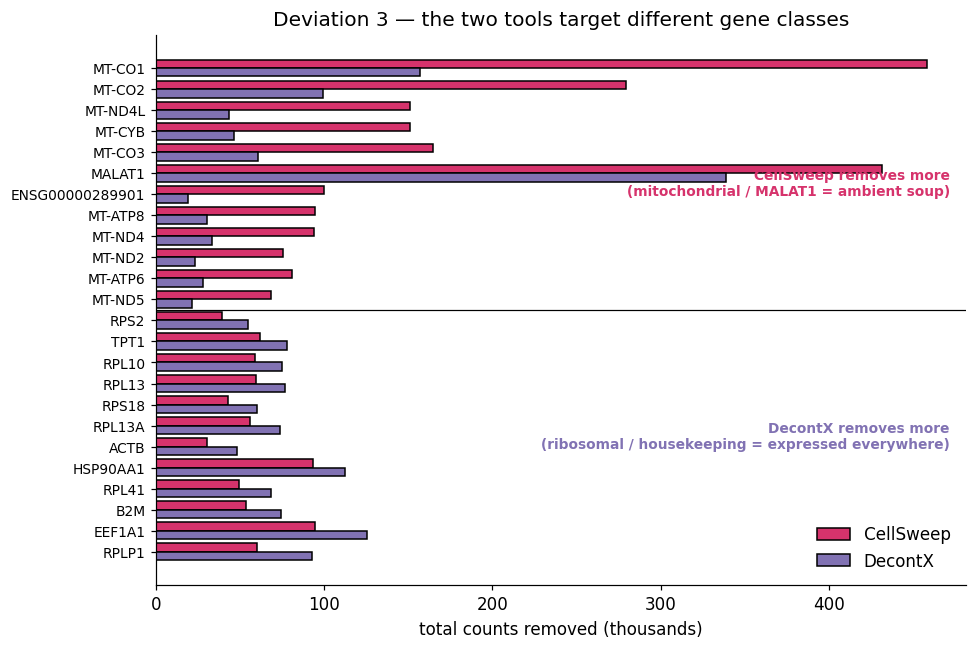

CellSweep-removes-more: ['MT-CO1', 'MT-CO2', 'MT-ND4L', 'MT-CYB', 'MT-CO3', 'MALAT1', 'ENSG00000289901', 'MT-ATP8', 'MT-ND4', 'MT-ND2', 'MT-ATP6', 'MT-ND5']
DecontX-removes-more:   ['RPS2', 'TPT1', 'RPL10', 'RPL13', 'RPS18', 'RPL13A', 'ACTB', 'HSP90AA1', 'RPL41', 'B2M', 'EEF1A1', 'RPLP1']


In [18]:
# Which gene classes does each tool preferentially remove?
rem_cs = np.asarray((raw-cs).sum(0)).ravel(); rem_dx = np.asarray((raw-dx).sum(0)).ravel()
names = np.array(a.var_names); diff = rem_cs - rem_dx
N = 12
dx_more = np.argsort(diff)[:N][::-1]      # DecontX removes more (diff most negative)
cs_more = np.argsort(diff)[::-1][:N]      # CellSweep removes more (diff most positive)
sel = list(cs_more) + list(dx_more)
fig, ax = plt.subplots(figsize=(9.5, 6.5)); yy = np.arange(len(sel))
ax.barh(yy-0.2, rem_cs[sel]/1e3, 0.4, label="CellSweep", color=TOOL_COLOR["cellsweep"], edgecolor="k")
ax.barh(yy+0.2, rem_dx[sel]/1e3, 0.4, label="DecontX",   color=TOOL_COLOR["decontx"], edgecolor="k")
ax.set_yticks(yy); ax.set_yticklabels(names[sel], fontsize=9); ax.invert_yaxis()
ax.axhline(N-0.5, color="k", lw=.8)
ax.text(ax.get_xlim()[1]*0.98, N/2-0.5, "CellSweep removes more\n(mitochondrial / MALAT1 = ambient soup)",
        ha="right", va="center", fontsize=9, color=TOOL_COLOR["cellsweep"], fontweight="bold")
ax.text(ax.get_xlim()[1]*0.98, N+N/2-0.5, "DecontX removes more\n(ribosomal / housekeeping = expressed everywhere)",
        ha="right", va="center", fontsize=9, color=TOOL_COLOR["decontx"], fontweight="bold")
ax.set_xlabel("total counts removed (thousands)")
ax.set_title("Deviation 3 — the two tools target different gene classes")
ax.legend(frameon=False, loc="lower right")
plt.savefig(f"{OUT}/fig12_divergent_genes.png"); plt.show()
print("CellSweep-removes-more:", list(names[cs_more]))
print("DecontX-removes-more:  ", list(names[dx_more]))

**What the deviation means.** The three differences are one story told three ways. CellSweep's celltype‑aware model gives each cell type its own expression profile and a constrained ambient fraction, so it removes the genuine soup (mitochondrial transcripts, MALAT1) roughly evenly and **protects rare populations and their markers**. DecontX's cluster‑level contamination estimate becomes unstable on small clusters, so it **over‑strips rare cell types** (cytotoxic T cells, Tregs, endothelium — 17–37% of their counts) and erodes their markers, while preferentially removing highly‑expressed housekeeping/ribosomal genes. In a tumor, the rare lymphocyte and stromal populations are usually the biologically decisive ones, so this is where the choice between the two best tools actually matters.

## 7. Summary

On a primary human melanoma tumor, ambient tumor‑RNA produces a concrete, clinically meaningful artifact: **melanoma antigens (`MLANA`, `PMEL`/gp100, `TYR`, `DCT`, `PRAME`, `S100B`, `MITF`, `SOX10`, …) appear as false positives across the immune compartment** — in up to ~5% of T cells for `S100B`.

Measured by **sensitivity and specificity** (Section 4), CellSweep, SoupX and DecontX look nearly interchangeable — which is exactly why those summary numbers are not enough. The **differential‑expression analysis** (Section 5) separates them cleanly:

| Tool | What the DE reveals |
|------|---------------------|
| **CellBender** | Under‑corrects — false‑positive antigen⁺ T cells remain; inflates some fold‑changes |
| **SoupX** | Under‑corrects — `S100B`/`PMEL`/`MC1R` still detected in hundreds of T cells |
| **scAR** | Over‑corrects — **loses `MC1R` & `TYRP1` as markers**, extreme fold‑changes |
| **DecontX** | Matches the summary metrics but **destabilises effect sizes** (fold‑changes 28–35) and erodes tumor signal |
| **CellSweep** | **Recovers every marker, keeps effect sizes calibrated, and leaves clean per‑cell calls** — the only tool passing all three |

**The finding:** tools that are statistically indistinguishable on count‑ and cell‑level sensitivity/specificity diverge sharply once you run the differential‑expression analysis those matrices exist for. CellSweep is the only one whose tumor DE is simultaneously sensitive, specific, calibrated and clean at single‑cell resolution — so it is the tool that lets you trust melanoma‑antigen calls and tumor differential expression in the microenvironment.

*Figures written to `notebooks/output/melanoma_discovery/`.*